# AGL — RoBERTa Fine-Tuning (Heavy Workload)

**Adaptive Guardrail Layer (AGL) — Binary Prompt Safety Classifier**

Fine-tunes `roberta-base` on the AGL binary dataset with **increased workload** for more training data.
This notebook is designed for **local execution** (NVIDIA GPU with CUDA).

**Data source:** `data/processed/dataset_feature_engineered.csv`

**Differences from baseline (train_roberta_local.ipynb):**
- Max samples per class: 25,000 (vs 15,000 baseline)
- Epochs: 5 (vs 3 baseline)
- Batch size: 48 (vs 32 baseline)
- Early stopping patience: 3 (vs 2 baseline)

In [1]:
# ── 1. Setup ────────────────────────────────────────────────────────────────
import os
import sys

# Set working directory to project root (parent of notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(PROJECT_ROOT)
elif not os.path.exists('src/config.py'):
    if os.path.exists('../src/config.py'):
        os.chdir('..')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f"Working directory: {os.getcwd()}")
assert os.path.exists('src/config.py'), "Not in project root — run from the notebooks/ or project root directory"

Working directory: /home/admin/git/aai-590-group-8-capstone


In [2]:
# ── 2. Check environment ────────────────────────────────────────────────────
import torch

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")

if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = "mps"
    print(f"Device: MPS (Apple Silicon)")
elif torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"Device: CUDA — {torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print(f"Device: CPU (training will be slow but it works)")

# Verify data exists
data_csv = 'data/processed/dataset_feature_engineered.csv'
assert os.path.exists(data_csv), f"Data not found at {data_csv}. Run the data pipeline notebooks first."
print(f"\nData: {data_csv} ✓")

Python: 3.14.2 (main, Jan 10 2026, 20:53:44) [GCC 15.2.1 20260103]
PyTorch: 2.10.0+cu128
Device: CUDA — NVIDIA GeForce RTX 5070 Ti

Data: data/processed/dataset_feature_engineered.csv ✓


## Step 3: Build Dataset (Heavy)

Load CSV, deduplicate, balance (25k per class), and split into train/val/test parquets.

In [3]:
# ── 3. Build dataset (HEAVY - 25k per class) ───────────────────────────────
# Override the max samples per class for heavier training
import pandas as pd
from src.config import MAX_SAMPLES_PER_CLASS

# Temporarily override for heavier dataset
original_max = MAX_SAMPLES_PER_CLASS
import src.config as cfg
cfg.MAX_SAMPLES_PER_CLASS = 25000  # Heavy: 25k per class (50k total)

from src.data.build_dataset import build_dataset

splits = build_dataset(csv_path='data/processed/dataset_feature_engineered.csv')

for name, df in splits.items():
    print(f"  {name}: {len(df)} samples")

# Restore original
cfg.MAX_SAMPLES_PER_CLASS = original_max


Building AGL dataset (binary classification)

Loaded 104755 samples from data/processed/dataset_feature_engineered.csv
  Label distribution: {0: 55108, 1: 49647}
  Dedup removed 5665 duplicates

After dedup: 99090 samples

After balancing: 50000 samples
Label distribution:
label_name
Benign       25000
Malicious    25000
Saved train: 34999 samples -> /home/admin/git/aai-590-group-8-capstone/data/processed/train.parquet
Saved val: 7500 samples -> /home/admin/git/aai-590-group-8-capstone/data/processed/val.parquet
Saved test: 7501 samples -> /home/admin/git/aai-590-group-8-capstone/data/processed/test.parquet
Saved metadata -> /home/admin/git/aai-590-group-8-capstone/data/processed/dataset_metadata.json
  train: 34999 samples
  val: 7500 samples
  test: 7501 samples


In [4]:
# ── 3b. Verify dataset ──────────────────────────────────────────────────────
import pandas as pd
from src.config import ID2LABEL

for split in ['train', 'val', 'test']:
    df = pd.read_parquet(f'data/processed/{split}.parquet')
    print(f"\n{split}: {len(df)} samples")
    label_counts = df['label'].value_counts()
    for label_id, count in label_counts.items():
        print(f"  {ID2LABEL[label_id]}: {count}")


train: 34999 samples
  Malicious: 17500
  Benign: 17499

val: 7500 samples
  Malicious: 3750
  Benign: 3750

test: 7501 samples
  Benign: 3751
  Malicious: 3750


## Step 4: Fine-Tune RoBERTa (Heavy)

Train the binary classifier with **heavier workload**:
- LR: 2e-5, warmup: 10%, weight decay: 0.01
- **Batch: 48** (vs 32 baseline)
- **Epochs: 5** (vs 3 baseline)
- **Early stopping patience: 3** (vs 2 baseline)
- Max sequence length: 128
- 2 classes: Benign (0), Malicious (1)

In [5]:
# ── 4. Train RoBERTa classifier (HEAVY) ─────────────────────────────────────
# Override training parameters for heavier workload
import src.config as cfg

# Save original values
orig_batch = cfg.TRAIN_BATCH_SIZE
orig_epochs = cfg.NUM_EPOCHS
orig_patience = cfg.EARLY_STOPPING_PATIENCE

# Apply heavy settings
cfg.TRAIN_BATCH_SIZE = 48      # Larger batch
cfg.NUM_EPOCHS = 5             # More epochs
cfg.EARLY_STOPPING_PATIENCE = 3  # More patience

from src.training.train import train_classifier

best_path = train_classifier()
print(f"\nBest model saved to: {best_path}")

# Restore original
cfg.TRAIN_BATCH_SIZE = orig_batch
cfg.NUM_EPOCHS = orig_epochs
cfg.EARLY_STOPPING_PATIENCE = orig_patience

/home/admin/git/aai-590-group-8-capstone/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 34999/34999 [00:00<00:00, 37329.24 examples/s]


Tokenized train: 34999 samples


Map: 100%|██████████| 7500/7500 [00:00<00:00, 31983.96 examples/s]


Tokenized val: 7500 samples


Map: 100%|██████████| 7501/7501 [00:00<00:00, 35883.06 examples/s]


...


[Epoch 4] val_loss=0.2843  macro_f1=0.9268  accuracy=0.9268


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.51it/s]



[Epoch 5] val_loss=0.3087  macro_f1=0.9323  accuracy=0.9323


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


Best model saved → /home/admin/git/aai-590-group-8-capstone/models/classifier/best

Best model saved to: /home/admin/git/aai-590-group-8-capstone/models/classifier/best


## Step 5: Evaluate

Run the full evaluation suite: keyword baseline, TF-IDF/SVM baseline, RoBERTa classifier.

In [6]:
# ── 6. Run evaluation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from src.config import MODELS_DIR, PROCESSED_DIR, RESULTS_DIR
from src.evaluation.metrics import evaluate_predictions, save_results
from src.evaluation.baselines import keyword_blocklist_baseline, tfidf_svm_baseline

# Load test data
train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
y_true = test_df['label'].values

print("=" * 60)
print("Running evaluation suite (HEAVY model)")
print("=" * 60)

all_results = {}

# Baseline 1: Keyword blocklist
print("\n[1/3] Keyword blocklist baseline...")
kw_preds = keyword_blocklist_baseline(test_df)
kw_results = evaluate_predictions(y_true, kw_preds)
all_results['keyword_blocklist'] = kw_results
print(f"  Macro-F1: {kw_results['macro_f1']:.4f}")

# Baseline 2: TF-IDF + SVM
print("\n[2/3] TF-IDF + LinearSVM baseline...")
svm_preds, _ = tfidf_svm_baseline(train_df, test_df)
svm_results = evaluate_predictions(y_true, svm_preds)
all_results['tfidf_svm'] = svm_results
print(f"  Macro-F1: {svm_results['macro_f1']:.4f}")

# RoBERTa
checkpoint = MODELS_DIR / 'classifier' / 'best'
if checkpoint.exists():
    print("\n[3/3] RoBERTa classifier (HEAVY)...")
    from src.models.agl_pipeline import AGLPipeline
    pipeline = AGLPipeline.from_checkpoint(checkpoint)
    roberta_preds = np.array([pipeline.predict(t).label_id for t in test_df['text']])
    roberta_results = evaluate_predictions(y_true, roberta_preds)
    all_results['roberta_heavy'] = roberta_results
    print(f"  Macro-F1: {roberta_results['macro_f1']:.4f}")
else:
    print(f"\n[3/3] Skipping RoBERTa — no checkpoint at {checkpoint}")

save_results(all_results, 'evaluation_results_heavy', RESULTS_DIR)

print("\n" + "=" * 60)
print("Summary — Macro-F1 Scores:")
print("=" * 60)
for method, res in all_results.items():
    print(f"  {method:25s} {res['macro_f1']:.4f}")

Running evaluation suite (HEAVY model)

[1/3] Keyword blocklist baseline...
  Macro-F1: 0.3690

[2/3] TF-IDF + LinearSVM baseline...
  Macro-F1: 0.8643

[3/3] RoBERTa classifier (HEAVY)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 40471.18it/s]


  Macro-F1: 0.9260
Saved results → /home/admin/git/aai-590-group-8-capstone/results/evaluation_results_heavy.json

Summary — Macro-F1 Scores:
  keyword_blocklist         0.3690
  tfidf_svm                 0.8643
  roberta_heavy             0.9260


## Step 6: Visualizations

Generate figures: confusion matrix, F1 comparison, ROC curve.

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 36431.23it/s]


Saved → /home/admin/git/aai-590-group-8-capstone/results/figures/confusion_matrix_roberta_heavy.png
Saved → /home/admin/git/aai-590-group-8-capstone/results/figures/f1_comparison_heavy.png
Saved → /home/admin/git/aai-590-group-8-capstone/results/figures/roc_curve_roberta_heavy.png

RoBERTa (Heavy) Results:
  Macro-F1:  0.9260
  ROC-AUC:   0.9789647560650493
  PR-AUC:    0.9817961050776803

Latency: mean=4.3ms, p99=5.9ms
Saved results → /home/admin/git/aai-590-group-8-capstone/results/roberta_heavy_evaluation.json

All figures saved to: /home/admin/git/aai-590-group-8-capstone/results/figures


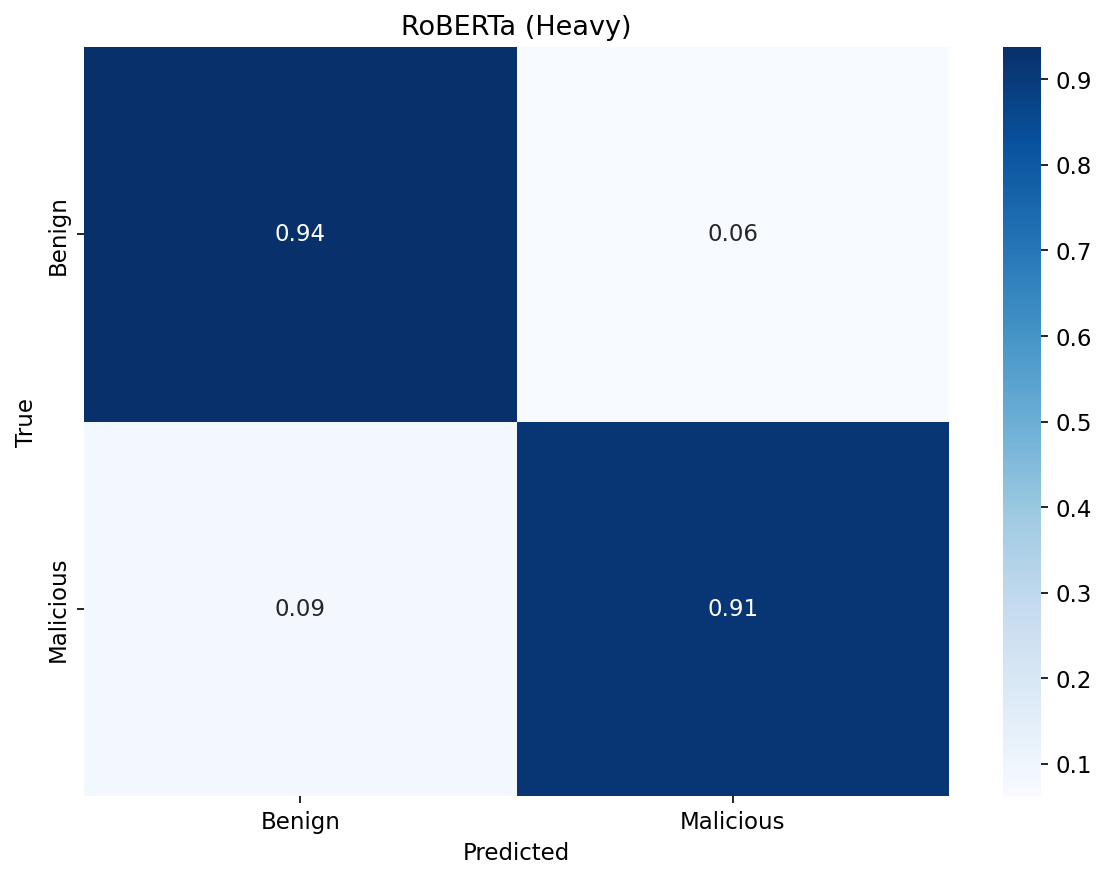

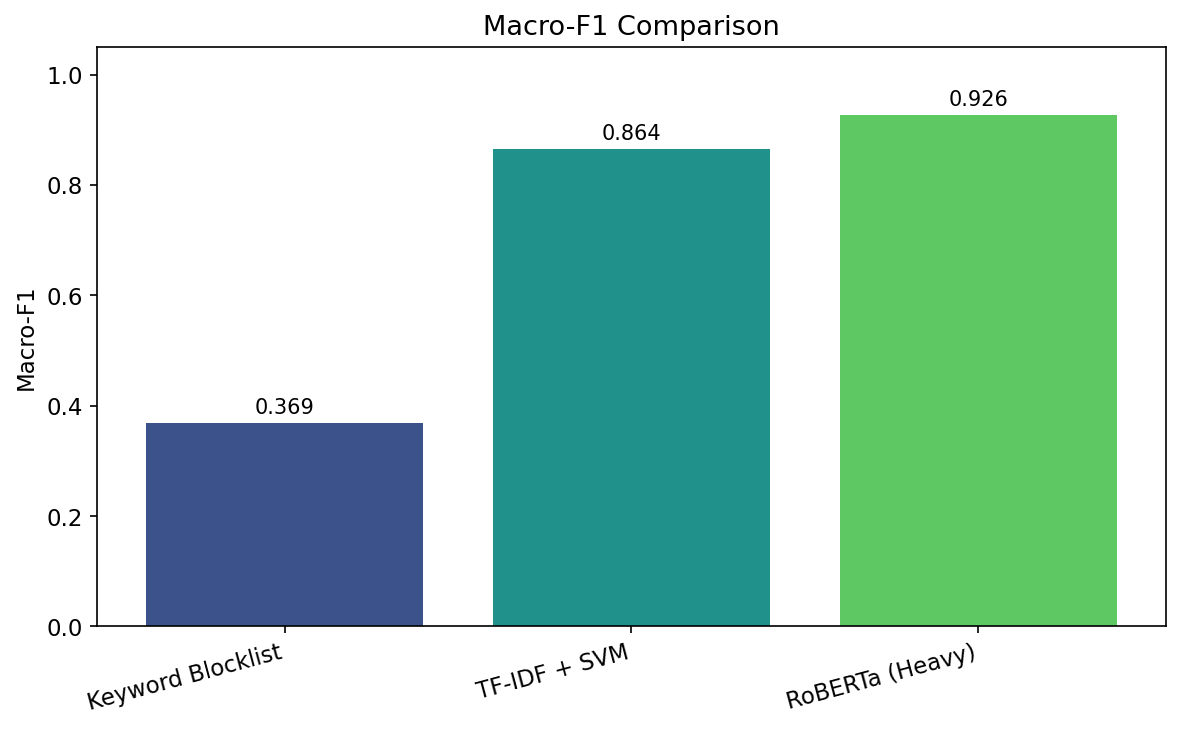

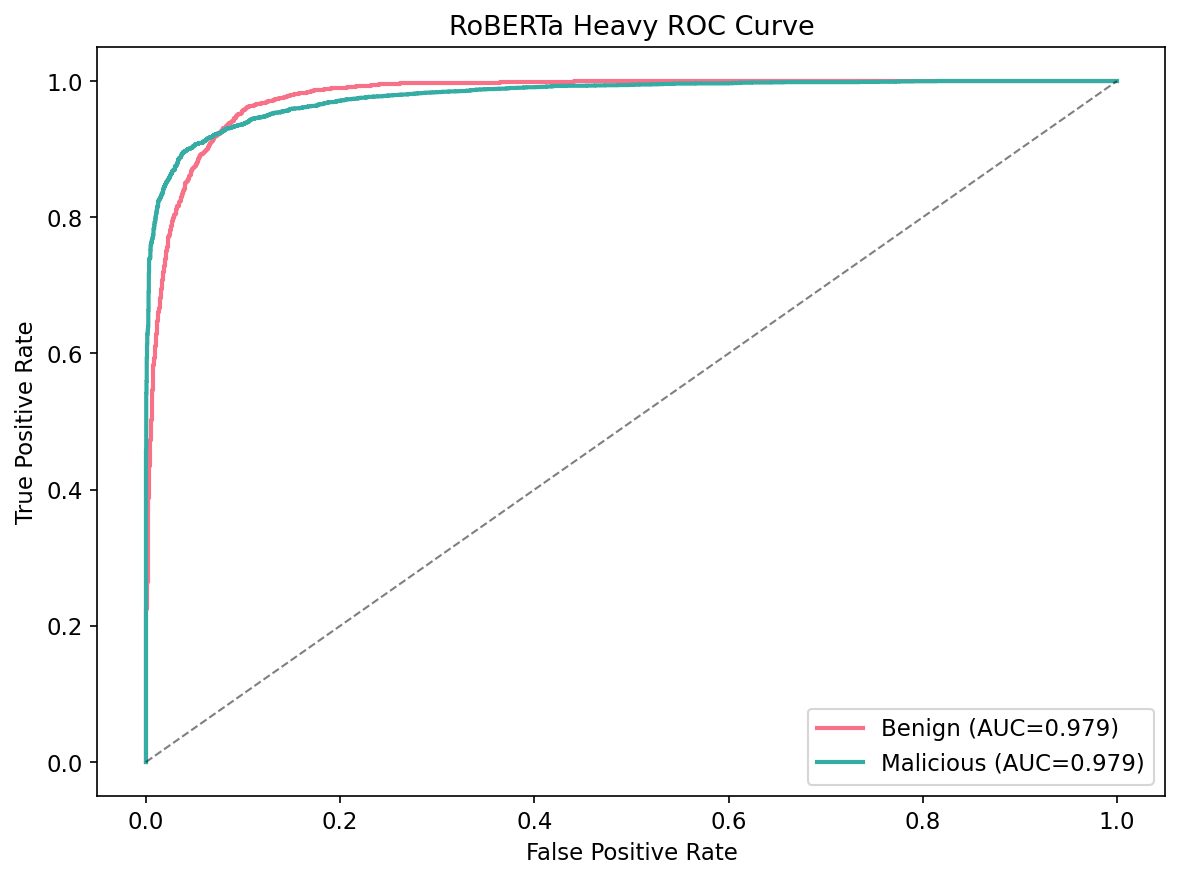

In [7]:
# ── 7. Generate visualizations ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
from src.config import RESULTS_DIR, FIGURES_DIR, PROCESSED_DIR, MODELS_DIR, MAX_SEQ_LENGTH
from src.evaluation.visualizations import (
    plot_confusion_matrix, plot_f1_comparison, plot_roc_curves
)
from src.evaluation.metrics import evaluate_predictions, benchmark_latency, save_results
from src.evaluation.baselines import keyword_blocklist_baseline, tfidf_svm_baseline
from src.models.agl_pipeline import AGLPipeline
from transformers import AutoTokenizer

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load test data
test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
y_true = test_df['label'].values

# Baselines
kw_preds = keyword_blocklist_baseline(test_df)
svm_preds, _ = tfidf_svm_baseline(train_df, test_df)

# RoBERTa predictions + probabilities (for ROC-AUC)
checkpoint = MODELS_DIR / 'classifier' / 'best'
pipeline = AGLPipeline.from_checkpoint(checkpoint)
tokenizer = AutoTokenizer.from_pretrained(str(checkpoint), local_files_only=True)

roberta_preds = []
roberta_probs = []
for text in test_df['text']:
    pred = pipeline.predict(text)
    roberta_preds.append(pred.label_id)
    inputs = tokenizer(text, truncation=True, padding='max_length',
                       max_length=MAX_SEQ_LENGTH, return_tensors='pt')
    inputs = {k: v.to(pipeline.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = pipeline.model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    roberta_probs.append(probs)

roberta_preds = np.array(roberta_preds)
roberta_probs = np.array(roberta_probs)

# ── Confusion matrix ──
plot_confusion_matrix(y_true, roberta_preds, title='RoBERTa (Heavy)',
                      save_path=FIGURES_DIR / 'confusion_matrix_roberta_heavy.png')

# ── F1 comparison ──
from sklearn.metrics import f1_score
f1_results = {
    'Keyword Blocklist': f1_score(y_true, kw_preds, average='macro', zero_division=0),
    'TF-IDF + SVM': f1_score(y_true, svm_preds, average='macro', zero_division=0),
    'RoBERTa (Heavy)': f1_score(y_true, roberta_preds, average='macro', zero_division=0),
}
plot_f1_comparison(f1_results, save_path=FIGURES_DIR / 'f1_comparison_heavy.png')

# ── ROC Curve ──
plot_roc_curves(y_true, roberta_probs, title='RoBERTa Heavy ROC Curve',
                save_path=FIGURES_DIR / 'roc_curve_roberta_heavy.png')

# ── Full evaluation with AUC ──
results = evaluate_predictions(y_true, roberta_preds, y_prob=roberta_probs)
print(f"\nRoBERTa (Heavy) Results:")
print(f"  Macro-F1:  {results['macro_f1']:.4f}")
print(f"  ROC-AUC:   {results.get('roc_auc', 'N/A')}")
print(f"  PR-AUC:    {results.get('pr_auc', 'N/A')}")

# ── Latency ──
latency = benchmark_latency(pipeline, test_df['text'].head(50).tolist(), n_runs=2)
print(f"\nLatency: mean={latency['mean_ms']:.1f}ms, p99={latency['p99_ms']:.1f}ms")

# ── Save results JSON ──
all_results = {
    'roberta_heavy': {**results, 'latency': latency}
}
save_results(all_results, 'roberta_heavy_evaluation', RESULTS_DIR)
print('\nAll figures saved to:', FIGURES_DIR)

## Step 7: Done

Model checkpoint saved to `models/classifier/best/`, results to `results/`.

In [8]:
# ── 7. Summary ──────────────────────────────────────────────────────────────
from pathlib import Path

print("Heavy Training Complete!")
print("Artifacts saved locally:")
for p in ['models/classifier/best', 'results']:
    exists = "✓" if Path(p).exists() else "✗"
    print(f"  {exists} {p}")

print("\nComparison with baseline:")
print("  Baseline (train_roberta_local.ipynb): 15k samples/class, 3 epochs, batch 32")
print("  Heavy (this notebook): 25k samples/class, 5 epochs, batch 48")

Heavy Training Complete!
Artifacts saved locally:
  ✓ models/classifier/best
  ✓ results

Comparison with baseline:
  Baseline (train_roberta_local.ipynb): 15k samples/class, 3 epochs, batch 32
  Heavy (this notebook): 25k samples/class, 5 epochs, batch 48
